In [1]:
# %pip install openpyxl

In [2]:
import pandas as pd
import numpy as np

# viz...
import seaborn as sns
import matplotlib.pyplot as plt


# my own custom lib
import vizion as vz

In [3]:
df = pd.read_excel("Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
vz.help_steps()

=== VIZION CLASS STEP-BY-STEP GUIDE ===
STEP 1: Load your dataset into a pandas DataFrame (df).
STEP 2: Quick overview of data:
        Vizion.quick_summary(df)  # basic stats and missing info
STEP 3: Check missing values in detail:
        Vizion.missing_value_summary(df)
STEP 4: Set global column types (numeric, categorical, missing):
        Vizion.get_column_types(df)
STEP 5: Handle missing values:
        df_clean, report = Vizion.handle_missing(df)  # drops/fills missing
STEP 6: Explore numeric columns with visual EDA:
        Vizion.plot_numeric_eda(df_clean)  # hist, box, kde, scatter
STEP 7: Explore categorical columns with visual EDA:
        Vizion.plot_categorical_eda(df_clean)  # count, bar, box, pie
STEP 8: Detect and handle outliers:
        df_clean = Vizion.handle_outliers(df_clean)  # cap/remove outliers
STEP 9: After EDA, you can perform feature engineering, encoding, scaling etc.
STEP 10: Build models (optional guidance):
        Use 'next_steps(df_clean, target="yo

In [6]:
vz.quick_summary(df)

===== SIMPLE DATA SUMMARY =====
Rows       : 541909
Columns    : 8
Numeric    : 3
Categorical: 4
Datetime   : 1
Missing columns: 2
Duplicated rows: 5268

Top Missing Columns (%):
  - CustomerID: 24.93%
  - Description: 0.27%

Top Missing Categorical Columns (%):
  - Description: 0.27%


In [7]:
num_col = df.select_dtypes(include=[np.number]).columns.tolist()
cat_col = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
mis_col = df.columns[df.isnull().sum() > 0].tolist()

In [8]:
df['CustomerID'].value_counts()
df['CustomerID'].nunique()

4372

In [9]:
df['StockCode'].value_counts()

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
          ... 
85179a       1
23617        1
90214U       1
47591b       1
72802c       1
Name: count, Length: 4070, dtype: int64

In [10]:
df[mis_col].value_counts()

Description                       CustomerID
CARRIAGE                          14911.0       85
CHILLI LIGHTS                     17841.0       65
REGENCY CAKESTAND 3 TIER          14911.0       56
PACK OF 60 DINOSAUR CAKE CASES    17841.0       54
BLUE/CREAM STRIPE CUSHION COVER   17841.0       54
                                                ..
ZINC WIRE SWEETHEART LETTER TRAY  17530.0        1
CHILDS GARDEN TROWEL PINK         17611.0        1
ZINC WIRE SWEETHEART LETTER TRAY  17812.0        1
                                  17835.0        1
                                  13405.0        1
Name: count, Length: 269157, dtype: int64

In [11]:
df= df.dropna(subset=["CustomerID"])

#### Justification : Dropping rows with missing CustomerID for RFM/customer analysis

In [12]:
vz.quick_summary(df)

===== SIMPLE DATA SUMMARY =====
Rows       : 406829
Columns    : 8
Numeric    : 3
Categorical: 4
Datetime   : 1
Missing columns: 0
Duplicated rows: 5225

Top Missing Columns (%):

Top Missing Categorical Columns (%):
  No missing categorical columns


In [13]:
for i in df.columns.to_list():
    print(i," : ",df[i].unique())
    print('----------------------------------------')

InvoiceNo  :  [536365 536366 536367 ... 581585 581586 581587]
----------------------------------------
StockCode  :  ['85123A' 71053 '84406B' ... '90214Z' 90089 23843]
----------------------------------------
Description  :  ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'PINK CRYSTAL SKULL PHONE CHARM'
 'CREAM HANGING HEART T-LIGHT HOLDER' 'PAPER CRAFT , LITTLE BIRDIE']
----------------------------------------
Quantity  :  [     6      8      2     32      3      4     24     12     48     18
     20     36     80     64     10    120     96     23      5      1
     -1     50     40    100    192    432    144    288    -12    -24
     16      9    128     25     30     28      7     72    200    600
    480     -6     14     -2     -4     -5     -7     -3     11     70
    252     60    216    384     27    108     52  -9360     75    270
     42    240     90    320     17   1824    204     69    -36   -192
   -144    160   2880   

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [15]:
df[df.duplicated()].head(3)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom


## Same User Will Do Multiple Transactions

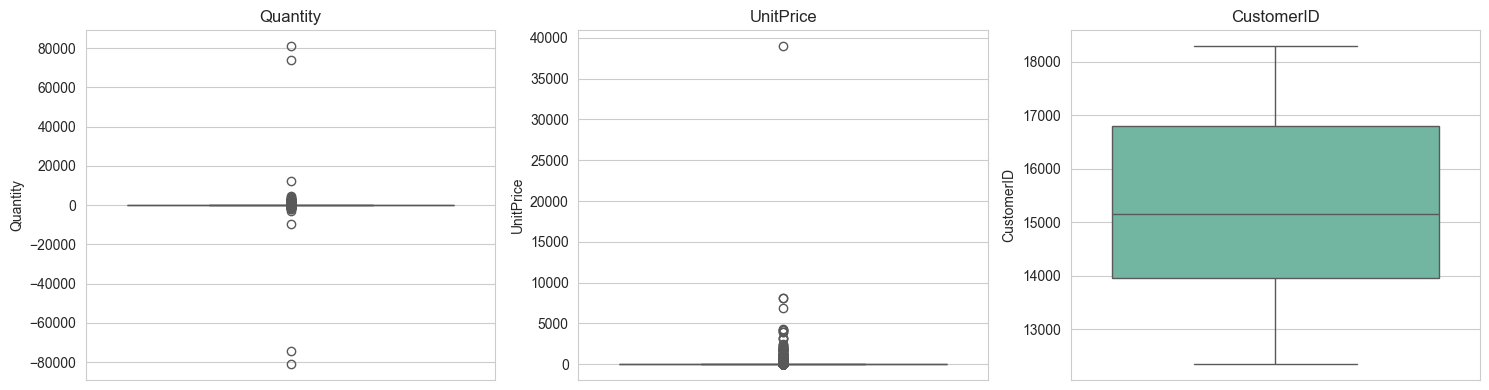

In [16]:
vz.plot_columns(df,df.select_dtypes(include=['int64','float64']).columns.to_list(),plot_type='box')

## Removing Unrealistic Extreme Values

<Axes: ylabel='Quantity'>

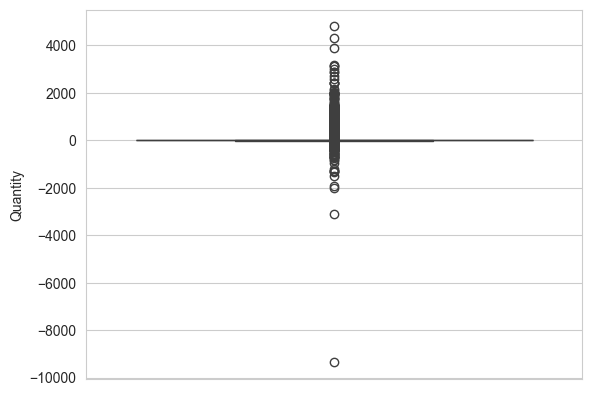

In [17]:
df = df[(df['Quantity'] > -10000) & (df['Quantity'] < 10000)]
sns.boxplot(data=df,y='Quantity')

In [18]:
df = df[(df['Quantity'] > -8000) & (df['Quantity'] < 10000)]


## About UnitPrice - some prices = 0 or negative, which is invalid.

In [19]:
df = df[df['UnitPrice'] > 0]

## CustomerID is not numerical feature it is categorical mean should be unique for each
### skipping CustomerID as Outliers / Missing

In [20]:
# converting string into datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Data Is ready For Visualization

In [21]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

# Q1 - Which Product And Customer Groups generate the highest revenue 

In [22]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

### Revenue By Month 

<Axes: xlabel='month'>

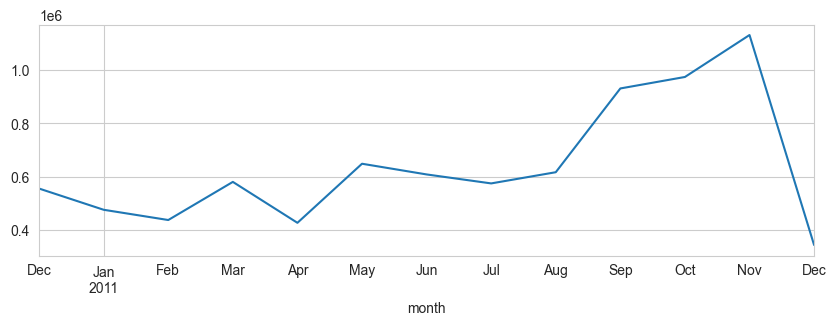

In [23]:
df["month"] = df["InvoiceDate"].dt.to_period("M")

monthly = df.groupby("month")["Revenue"].sum()
monthly.plot(kind="line",figsize=(10,3))

Insight:
Revenue changes a lot from month to month. Some months show very high sales, while others are low.
This means the business has seasonal demand — people buy more during certain months.
The CEO can use this pattern to plan stock, marketing, and offers during high-sales months.

## Top 10 product by revenue

<Axes: ylabel='Description'>

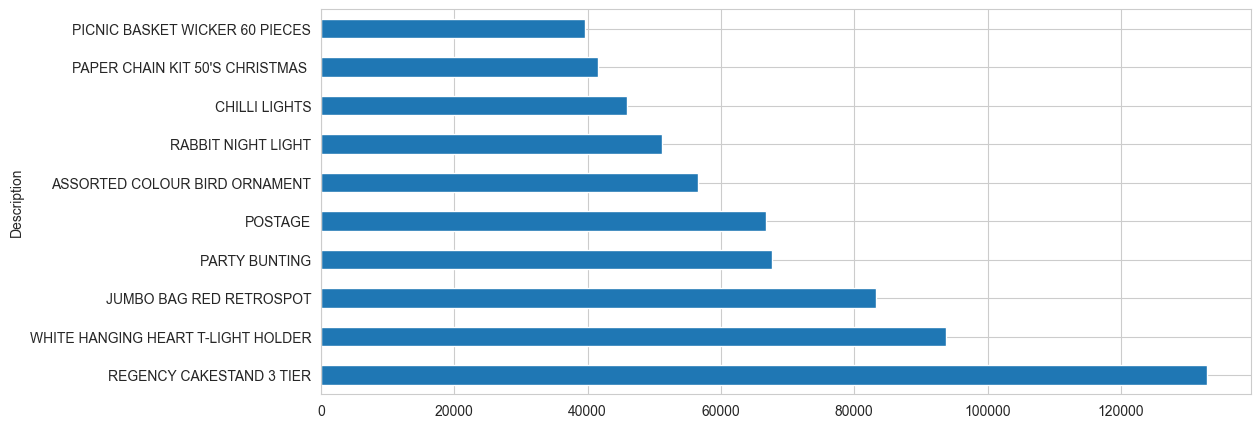

In [24]:
product_rev = df.groupby("Description")["Revenue"].sum().nlargest(10)
product_rev.plot.barh(figsize=(12,5))

Only a few products bring in most of the money.
These top 10 products are the main revenue drivers for the business.
The CEO should keep these products always in-stock, and the CMO should promote them more because they already sell well.

## Top Customers Revenue

<Axes: ylabel='CustomerID'>

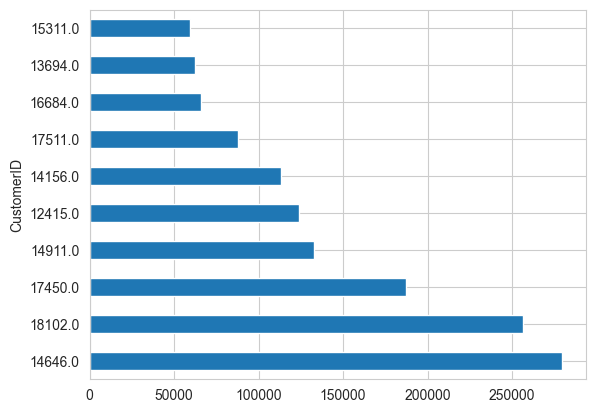

In [25]:
customer_rev = df.groupby("CustomerID")["Revenue"].sum().nlargest(10)
customer_rev.plot(kind='barh')

Some customers buy very frequently compared to others.
These are loyal customers who keep returning.
The CMO should target them with loyalty rewards, special offers, and personalized emails to keep them engaged.

## Revenue By Country

<Axes: ylabel='Country'>

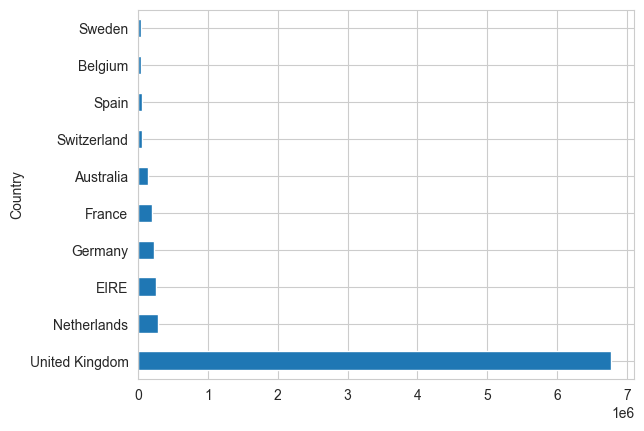

In [26]:
country_rev = df.groupby("Country")["Revenue"].sum().nlargest(10)
country_rev.plot(kind='barh')

The United Kingdom gives the highest revenue, much more than other countries.
This shows the UK is the company’s strongest market.
The CEO can focus expansions here, and work on improving sales in low-performing countries.

# Contribution of Top Customers

In [27]:
cum_perc = customer_rev.cumsum() / customer_rev.sum() * 100

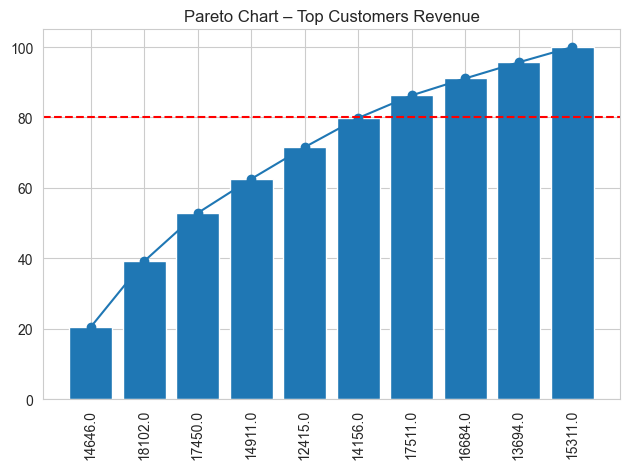

In [28]:
plt.Figure(figsize=(10,5))

# bar
plt.bar(customer_rev.index.astype(str),cum_perc.values)


# cumulative line
plt.plot(customer_rev.index.astype(str),cum_perc.values,'o-')


plt.axhline(80, color='red', linestyle='--')  # 80% line
plt.xticks(rotation=90)
plt.title("Pareto Chart – Top Customers Revenue")
plt.tight_layout()
plt.show()


# understand full code ----------


The top customers sorted by revenue

A cumulative line showing how much total revenue these customers contribute

A red 80% line showing where the Pareto principle (80/20 rule) hits

Only a few customers are giving most of the money.
If they stop buying, the business will lose a lot of revenue.

<Axes: title={'center': 'Top Customers by Purchase Frequency'}, xlabel='CustomerID'>

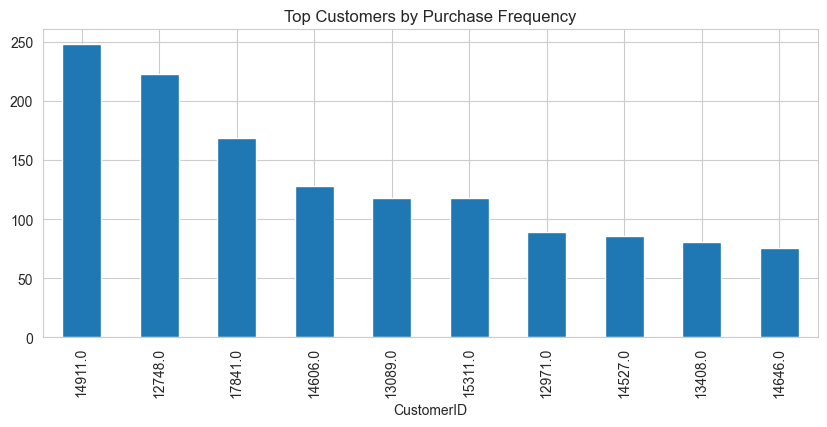

In [29]:
cust_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
cust_freq.nlargest(10).plot(kind='bar', figsize=(10,4), title="Top Customers by Purchase Frequency")
